# Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import plotly.express as px
import plotly.graph_objects as go

# Load Datasets

In [4]:
# Load the datasets
track_data = pd.read_csv('../data/track_data_final.csv')
spotify_clean = pd.read_csv('../data/spotify_data clean.csv')

# Display first few rows
print("Track Data:")
display(track_data.head())
print("\nSpotify Clean Data:")
display(spotify_clean.head())

Track Data:


,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,158463,True,Billie Eilish,90.0,118692183.0,[],0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,267013,False,Rihanna,90.0,68997177.0,[],5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album



Spotify Clean Data:


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


# Data Cleaning and Preprocessing

In [5]:
# Check for missing values
print("Missing values in track_data:")
print(track_data.isnull().sum())
print("\nMissing values in spotify_clean:")
print(spotify_clean.isnull().sum())

# Handle missing values (e.g., fill or drop)
track_data = track_data.dropna()
spotify_clean = spotify_clean.dropna()

# Check data types
print("\nData types in track_data:")
print(track_data.dtypes)
print("\nData types in spotify_clean:")
print(spotify_clean.dtypes)

# Convert date columns if any
# Assuming album_release_date is present
if 'album_release_date' in spotify_clean.columns:
    spotify_clean['album_release_date'] = pd.to_datetime(spotify_clean['album_release_date'], errors='coerce')

# Merge datasets if needed (e.g., on track_id)
# For simplicity, we'll work with them separately or merge on common columns
merged_data = pd.merge(track_data, spotify_clean, on='track_id', how='inner')
print(f"\nMerged data shape: {merged_data.shape}")
display(merged_data.head())

Missing values in track_data:
track_id              0
track_name            2
track_number          0
track_popularity      0
track_duration_ms     0
explicit              0
artist_name           4
artist_popularity     4
artist_followers      4
artist_genres         4
album_id              0
album_name            2
album_release_date    0
album_total_tracks    0
album_type            0
dtype: int64

Missing values in spotify_clean:
track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64

Data types in track_data:
track_id               object
track_name             object
track_number            int64
track_popularity        int6

,track_id,track_name_x,track_number_x,track_popularity_x,track_duration_ms,explicit_x,artist_name_x,artist_popularity_x,artist_followers_x,artist_genres_x,...,artist_name_y,artist_popularity_y,artist_followers_y,artist_genres_y,album_id_y,album_name_y,album_release_date_y,album_total_tracks_y,album_type_y,track_duration_min
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],...,Britney Spears,80,17755451,pop,325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation,3.55
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],...,BUNT.,69,293734,stutter house,2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single,2.64
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],...,Taylor Swift,100,145396321,"country, pop, indie, folk",4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album,3.75
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,158463,True,Billie Eilish,90.0,118692183.0,[],...,Billie Eilish,90,118692183,"alternative pop, electropop, dark pop",0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album,2.64
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,267013,False,Rihanna,90.0,68997177.0,[],...,Rihanna,90,68997177,"pop, r&b",5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album,4.45


# Exploratory Data Analysis - Summary Statistics

In [6]:
# Summary statistics for track_data
print("Track Data Summary:")
display(track_data.describe())

# Summary statistics for spotify_clean
print("Spotify Clean Summary:")
display(spotify_clean.describe())

# Correlation matrix
numeric_cols = track_data.select_dtypes(include=[np.number]).columns
correlation = track_data[numeric_cols].corr()
print("Correlation Matrix:")
display(correlation)

# Groupby operations (e.g., average popularity by artist)
if 'artist_name' in track_data.columns and 'track_popularity' in track_data.columns:
    avg_popularity = track_data.groupby('artist_name')['track_popularity'].mean().sort_values(ascending=False).head(10)
    print("Top 10 Artists by Average Track Popularity:")
    display(avg_popularity)

Track Data Summary:


,track_number,track_popularity,track_duration_ms,artist_popularity,artist_followers,album_total_tracks
count,8772.000000,8772.000000,8772.00000,8772.000000,8.772000e+03,8772.000000
mean,5.750456,52.243274,210201.45668,69.970930,2.435979e+07,13.783288
std,6.019187,24.068279,63263.55241,19.506421,3.814064e+07,11.798720
min,1.000000,0.000000,4388.00000,0.000000,0.000000e+00,1.000000
25%,1.000000,39.000000,173940.75000,60.000000,5.145230e+05,6.000000
50%,4.000000,58.000000,207276.00000,74.000000,6.284112e+06,13.000000
75%,9.000000,71.000000,239639.75000,84.000000,3.055055e+07,17.000000
max,102.000000,100.000000,811077.00000,100.000000,1.455421e+08,181.000000


Spotify Clean Summary:


,track_number,track_popularity,artist_popularity,artist_followers,album_release_date,album_total_tracks,track_duration_min
count,5221.000000,5221.000000,5221.000000,5.221000e+03,5221,5221.000000,5221.000000
mean,6.465237,53.555258,74.588776,3.383704e+07,2014-05-03 02:19:00.471174144,15.893124,3.564999
min,1.000000,0.000000,2.000000,4.000000e+00,1952-09-12 00:00:00,1.000000,0.140000
25%,1.000000,41.000000,63.000000,1.303279e+06,2010-12-01 00:00:00,10.000000,2.900000
50%,5.000000,59.000000,79.000000,1.096042e+07,2017-06-02 00:00:00,14.000000,3.510000
75%,10.000000,71.000000,88.000000,4.771699e+07,2022-02-17 00:00:00,19.000000,4.080000
max,102.000000,99.000000,100.000000,1.455421e+08,2025-10-31 00:00:00,181.000000,13.510000
std,6.324842,22.987208,17.178821,4.472907e+07,NaN,13.101610,1.133062


Correlation Matrix:


,track_number,track_popularity,track_duration_ms,artist_popularity,artist_followers,album_total_tracks
track_number,1.000000,-0.024850,0.069927,0.188654,0.221567,0.518399
track_popularity,-0.024850,1.000000,0.105795,0.454877,0.226420,-0.047898
track_duration_ms,0.069927,0.105795,1.000000,0.210187,0.175429,0.067189
artist_popularity,0.188654,0.454877,0.210187,1.000000,0.638162,0.199936
artist_followers,0.221567,0.226420,0.175429,0.638162,1.000000,0.186288
album_total_tracks,0.518399,-0.047898,0.067189,0.199936,0.186288,1.000000


Top 10 Artists by Average Track Popularity:


artist_name
HUNTR/X        93.750000
Saja Boys      93.500000
Disco Lines    92.000000
Rumi           91.000000
Olivia Dean    90.333333
The Police     90.000000
Djo            89.000000
W Sound        89.000000
KATSEYE        88.666667
Jin            88.000000
Name: track_popularity, dtype: float64

# Exploratory Data Analysis - Visualizations

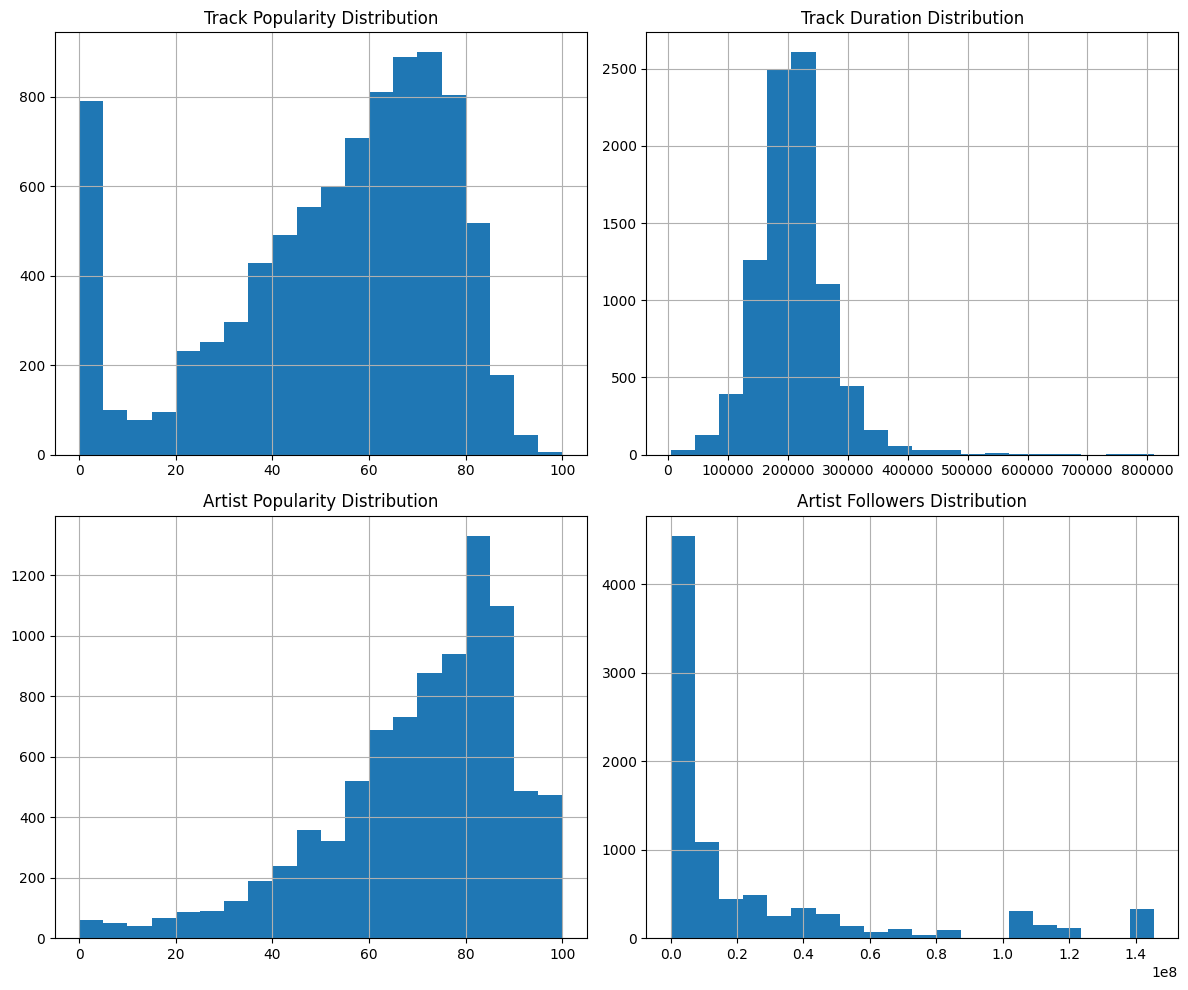

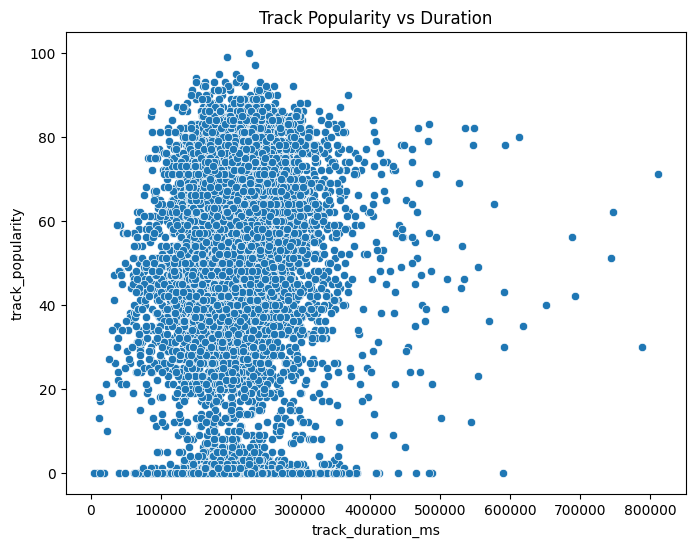

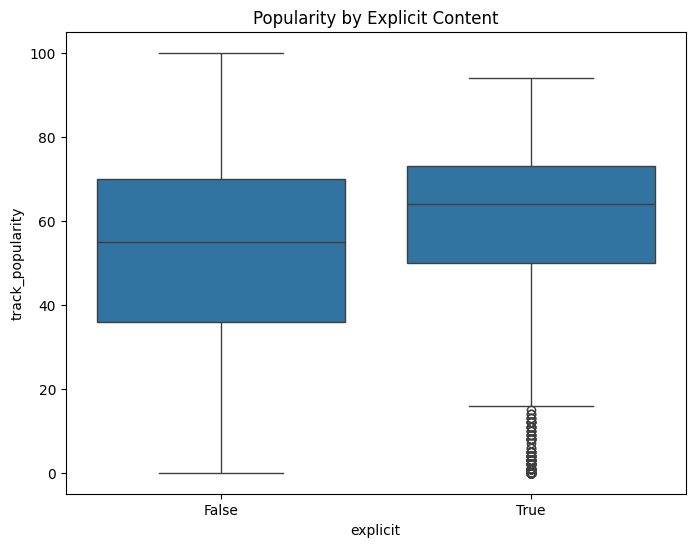

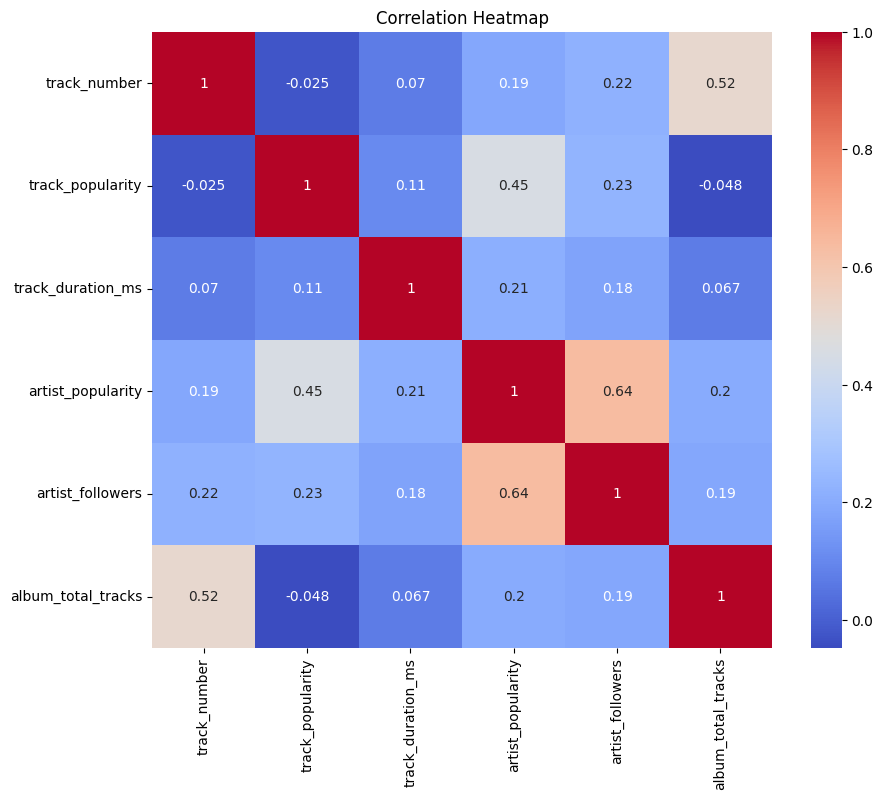

In [7]:
# Histograms for numeric features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
track_data['track_popularity'].hist(ax=axes[0,0], bins=20)
axes[0,0].set_title('Track Popularity Distribution')

track_data['track_duration_ms'].hist(ax=axes[0,1], bins=20)
axes[0,1].set_title('Track Duration Distribution')

if 'artist_popularity' in track_data.columns:
    track_data['artist_popularity'].hist(ax=axes[1,0], bins=20)
    axes[1,0].set_title('Artist Popularity Distribution')

if 'artist_followers' in track_data.columns:
    track_data['artist_followers'].hist(ax=axes[1,1], bins=20)
    axes[1,1].set_title('Artist Followers Distribution')

plt.tight_layout()
plt.show()

# Scatter plot: Popularity vs Duration
plt.figure(figsize=(8,6))
sns.scatterplot(data=track_data, x='track_duration_ms', y='track_popularity')
plt.title('Track Popularity vs Duration')
plt.show()

# Box plot for explicit content
if 'explicit' in track_data.columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(data=track_data, x='explicit', y='track_popularity')
    plt.title('Popularity by Explicit Content')
    plt.show()

# Heatmap for correlation
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Plotly interactive plot: Top genres
if 'artist_genres' in track_data.columns:
    genre_counts = track_data['artist_genres'].value_counts().head(10)
    fig = px.bar(genre_counts, x=genre_counts.index, y=genre_counts.values, title='Top 10 Artist Genres')
    fig.show()

# Feature Engineering

In [8]:
# Create new features
# Duration in minutes
track_data['duration_min'] = track_data['track_duration_ms'] / 60000

# Popularity category
track_data['popularity_category'] = pd.cut(track_data['track_popularity'], bins=[0, 30, 60, 100], labels=['Low', 'Medium', 'High'])

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
if 'explicit' in track_data.columns:
    track_data['explicit_encoded'] = le.fit_transform(track_data['explicit'])

# Prepare features for classification
features = ['track_duration_ms', 'artist_popularity', 'artist_followers', 'explicit_encoded']
target = 'popularity_category'  # or 'explicit' for binary classification

# Drop rows with missing target
model_data = track_data.dropna(subset=features + [target])

X = model_data[features]
y = model_data[target]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (8253, 4)
Target shape: (8253,)


# Classification Model Training

In [9]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


# Model Evaluation

Logistic Regression Metrics:
Accuracy: 0.5911568746214415
Precision: 0.6353817835496116
Recall: 0.5911568746214415


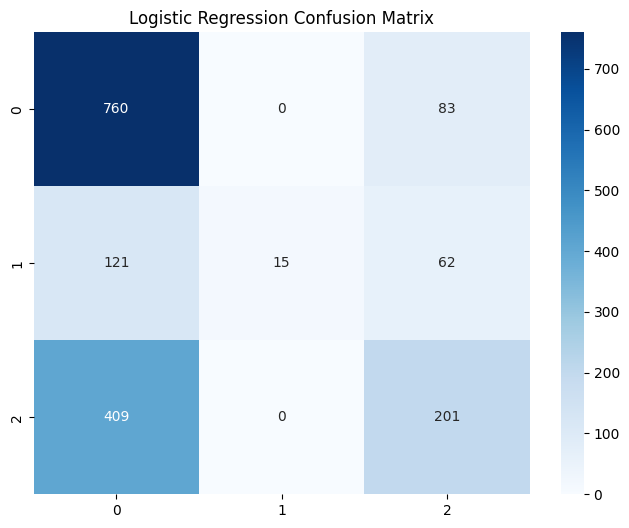

Random Forest Metrics:
Accuracy: 0.6165960024227741
Precision: 0.6108555701281958
Recall: 0.6165960024227741


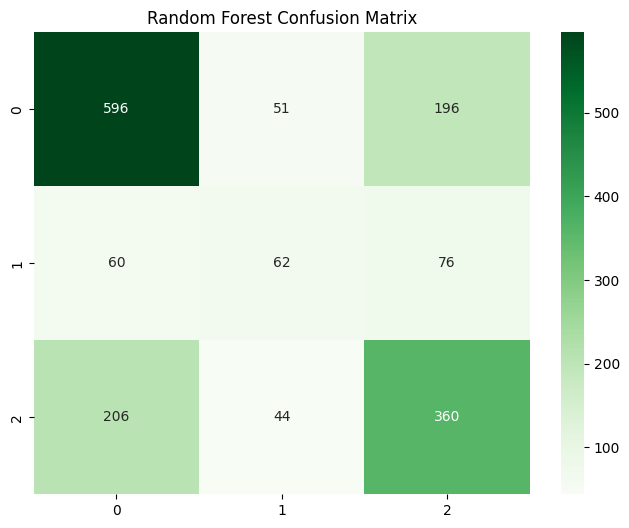

Models saved to ../models/


In [10]:
# Evaluate Logistic Regression
lr_pred = lr_model.predict(X_test)
print("Logistic Regression Metrics:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred)}")
print(f"Precision: {precision_score(y_test, lr_pred, average='weighted')}")
print(f"Recall: {recall_score(y_test, lr_pred, average='weighted')}")

# Confusion Matrix for LR
cm_lr = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Evaluate Random Forest
rf_pred = rf_model.predict(X_test)
print("Random Forest Metrics:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred)}")
print(f"Precision: {precision_score(y_test, rf_pred, average='weighted')}")
print(f"Recall: {recall_score(y_test, rf_pred, average='weighted')}")

# Confusion Matrix for RF
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Save models
import joblib
joblib.dump(lr_model, '../models/spotify_lr_model.joblib')
joblib.dump(rf_model, '../models/spotify_rf_model.joblib')
print("Models saved to ../models/")